# FIT file reading

https://developer.garmin.com/fit/file-types/


This notebook explores:
    
* https://developer.garmin.com/fit/example-projects/python/
* https://github.com/polyvertex/fitdecode

In [1]:
import arrow
import pandas as pd

# First, some files
workout_file = "data/HOP21/2024-02-20_HoP21-workout.fit"  # A Workout file
activity_file = "data/HOP21/zwift-activity-1548239133179133984.fit"  # An Activity file.

----

## Garmin Fit SDK & Workouts

See also: https://developer.garmin.com/fit/file-types/workout/


In [2]:
from garmin_fit_sdk import Decoder, Stream

stream = Stream.from_file(workout_file)
decoder = Decoder(stream)


if decoder.is_fit() and decoder.check_integrity():
    messages, errors = decoder.read()
else:
    errors = []
    messages = {"error": "not a valid fit file?"}

# errors is a list of errors (if any?)
messages.keys()  # types of messages in a FIT file

dict_keys(['file_id_mesgs', 'file_creator_mesgs', 'workout_step_mesgs', 'workout_mesgs'])

In [3]:
messages['file_id_mesgs']

[{'type': 'workout',
  'manufacturer': 'peaksware',
  'product': 0,
  'serial_number': 2407589616,
  'time_created': datetime.datetime(2024, 2, 21, 9, 9, 38, tzinfo=datetime.timezone.utc)}]

In [4]:
messages['file_creator_mesgs']

[{'software_version': 1}]

In [5]:
messages['workout_mesgs']

[{'sport': 'cycling',
  'wkt_name': '⏱ - House of Pain #21 - Gotta Push to Reach Those Goals - Z5 Round 2!',
  'num_valid_steps': 20}]

In [6]:
messages["workout_step_mesgs"]

[{'wkt_step_name': 'Warm up',
  'duration_value': 360000,
  'target_type': 'power',
  'target_value': 0,
  'custom_target_value_low': 1114,
  'custom_target_value_high': 1137,
  'intensity': 'warmup',
  'message_index': 0,
  'duration_type': 'time',
  'duration_time': 360.0,
  'target_power_zone': 0,
  'custom_target_power_low': 1114,
  'custom_target_power_high': 1137},
 {'wkt_step_name': 'Hard',
  'duration_value': 60000,
  'target_type': 'power',
  'target_value': 0,
  'custom_target_value_low': 1218,
  'custom_target_value_high': 1240,
  'intensity': 'active',
  'message_index': 1,
  'duration_type': 'time',
  'duration_time': 60.0,
  'target_power_zone': 0,
  'custom_target_power_low': 1218,
  'custom_target_power_high': 1240},
 {'wkt_step_name': 'Easy',
  'duration_value': 60000,
  'target_type': 'power',
  'target_value': 0,
  'custom_target_value_low': 1114,
  'custom_target_value_high': 1137,
  'intensity': 'rest',
  'message_index': 2,
  'duration_type': 'time',
  'duration_t

In [7]:
for d in messages['workout_step_mesgs']:
    dtype = d['duration_type']
    name = d.get('wkt_step_name', '?')
    mindex = d['message_index']
    dt = d.get('duration_time')
    dval = d.get('duration_value')
    z = d.get('target_power_zone')
    plow = d.get('custom_target_power_low')  # Range from 0 - 1000% of FTP.
    phi = d.get('custom_target_power_high')
    
    print(f"{mindex}:{name}:{dtype} -> {dt} ({dval}) -> {z}/{plow}/{phi}")
    

0:Warm up:time -> 360.0 (360000) -> 0/1114/1137
1:Hard:time -> 60.0 (60000) -> 0/1218/1240
2:Easy:time -> 60.0 (60000) -> 0/1114/1137
3:?:repeat_until_steps_cmplt -> None (1) -> None/None/None
4:Recovery:time -> 180.0 (180000) -> 0/1114/1126
5:Hard 3 min - working VO2:time -> 180.0 (180000) -> 0/1240/1252
6:Short recovery:time -> 60.0 (60000) -> 0/1114/1126
7:?:repeat_until_steps_cmplt -> None (5) -> None/None/None
8:Recovery:time -> 240.0 (240000) -> 0/1114/1126
9:Hard 3 min - working VO2:time -> 180.0 (180000) -> 0/1240/1263
10:Short recovery:time -> 60.0 (60000) -> 0/1114/1126
11:?:repeat_until_steps_cmplt -> None (9) -> None/None/None
12:Recovery:time -> 240.0 (240000) -> 0/1114/1126
13:Hard 3 min - working VO2:time -> 180.0 (180000) -> 0/1240/1263
14:Short recovery:time -> 60.0 (60000) -> 0/1114/1126
15:?:repeat_until_steps_cmplt -> None (13) -> None/None/None
16:Recovery:time -> 240.0 (240000) -> 0/1114/1126
17:Drills and skills work!:time -> 420.0 (420000) -> 0/1137/1183
18:Cool

In [8]:
#messages['workout_step_mesgs'][3]
messages['workout_step_mesgs'][-1]

{'intensity': 'cooldown', 'message_index': 19, 'duration_type': 'open'}

In [9]:
set(d['duration_type'] for d in messages['workout_step_mesgs'])

{'open', 'repeat_until_steps_cmplt', 'time'}

In [10]:
set(d.get('intensity') for d in messages['workout_step_mesgs'])

{None, 'active', 'cooldown', 'rest', 'warmup'}

In [11]:
df = pd.DataFrame(messages['workout_step_mesgs'])
df = df.set_index("message_index")

print(", ".join(df.columns))

# https://developer.garmin.com/fit/file-types/workout/#settingpowerandheartratevalues
# ...The integer range 0 to 100 (heart rate) and 0 to 1000 (power) are reserved for relative values, 
# absolute heart rate and power values must be offset by 100 bpm or 1000 watts respectively. 
df["pow_low"] = df.custom_target_power_low - 1000
df["pow_high"] = df.custom_target_power_high - 1000

xxx = df[["wkt_step_name","duration_type","duration_time","duration_step","repeat_steps","target_type","pow_low", "pow_high"]]
xxx

wkt_step_name, duration_value, target_type, target_value, custom_target_value_low, custom_target_value_high, intensity, duration_type, duration_time, target_power_zone, custom_target_power_low, custom_target_power_high, duration_step, repeat_steps


,wkt_step_name,duration_type,duration_time,duration_step,repeat_steps,target_type,pow_low,pow_high
message_index,,,,,,,,
0,Warm up,time,360.0,NaN,NaN,power,114.0,137.0
1,Hard,time,60.0,NaN,NaN,power,218.0,240.0
2,Easy,time,60.0,NaN,NaN,power,114.0,137.0
3,NaN,repeat_until_steps_cmplt,NaN,1.0,3.0,NaN,NaN,NaN
4,Recovery,time,180.0,NaN,NaN,power,114.0,126.0
5,Hard 3 min - working VO2,time,180.0,NaN,NaN,power,240.0,252.0
6,Short recovery,time,60.0,NaN,NaN,power,114.0,126.0
7,NaN,repeat_until_steps_cmplt,NaN,5.0,3.0,NaN,NaN,NaN
8,Recovery,time,240.0,NaN,NaN,power,114.0,126.0


In [12]:
## XXX ---> How to turn the above into a time-series 
## XXX -->>>> `durction_step` is the message_index that we go back to in order to repeat.
for row in df.itertuples(index=False):
    print(f"{row.wkt_step_name} / {row.duration_time} / {row.repeat_steps}")

Warm up / 360.0 / nan
Hard / 60.0 / nan
Easy / 60.0 / nan
nan / nan / 3.0
Recovery / 180.0 / nan
Hard 3 min - working VO2 / 180.0 / nan
Short recovery / 60.0 / nan
nan / nan / 3.0
Recovery / 240.0 / nan
Hard 3 min - working VO2 / 180.0 / nan
Short recovery / 60.0 / nan
nan / nan / 3.0
Recovery / 240.0 / nan
Hard 3 min - working VO2 / 180.0 / nan
Short recovery / 60.0 / nan
nan / nan / 3.0
Recovery / 240.0 / nan
Drills and skills work! / 420.0 / nan
Cool Down / 300.0 / nan
nan / nan / nan


## Garmin FIT SDK and Activity files

https://developer.garmin.com/fit/file-types/activity/

In [13]:
from garmin_fit_sdk import Decoder, Stream

stream = Stream.from_file(activity_file)
decoder = Decoder(stream)
messages, errors = decoder.read()
# errors is a list of errors (if any?)
errors, ", ".join(messages.keys())  # types of messages in a FIT file

([],
 'file_id_mesgs, device_info_mesgs, event_mesgs, record_mesgs, lap_mesgs, session_mesgs, activity_mesgs')

In [14]:
messages["file_id_mesgs"]

[{'time_created': datetime.datetime(2024, 2, 20, 23, 51, 44, tzinfo=datetime.timezone.utc),
  'manufacturer': 'zwift',
  'product': 0,
  'number': 0,
  'type': 'activity'}]

In [15]:
messages["device_info_mesgs"]

[{'timestamp': datetime.datetime(2015, 1, 6, 22, 8, 25, tzinfo=datetime.timezone.utc),
  'serial_number': 3825981698,
  'cum_operating_time': 0,
  'manufacturer': 'zwift',
  'product': 0,
  'software_version': 5.62,
  'battery_voltage': 0.0,
  'device_index': 'creator',
  'device_type': 0,
  'hardware_version': 0,
  'battery_status': 0}]

In [16]:
messages["event_mesgs"]

[{'timestamp': datetime.datetime(2024, 2, 20, 23, 51, 52, tzinfo=datetime.timezone.utc),
  'data': 0,
  'data16': 0,
  'event': 'timer',
  'event_type': 'start',
  'event_group': 0,
  'timer_trigger': 'manual'},
 {'timestamp': datetime.datetime(2024, 2, 21, 1, 15, 32, tzinfo=datetime.timezone.utc),
  'data': 0,
  'data16': 0,
  'event': 'timer',
  'event_type': 'stop_all',
  'event_group': 0,
  'timer_trigger': 'manual'}]

In [17]:
messages["activity_mesgs"]

[{'timestamp': datetime.datetime(2024, 2, 21, 1, 15, 32, tzinfo=datetime.timezone.utc),
  'total_timer_time': 5017.0,
  'local_timestamp': 0,
  'num_sessions': 1,
  'type': 'manual',
  'event': 'activity',
  'event_type': 'stop',
  'event_group': 0}]

In [18]:
messages["session_mesgs"]  # Summary of the activity.

[{'timestamp': datetime.datetime(2024, 2, 21, 1, 15, 32, tzinfo=datetime.timezone.utc),
  'start_time': datetime.datetime(2024, 2, 20, 23, 51, 52, tzinfo=datetime.timezone.utc),
  'start_position_lat': 0,
  'start_position_long': 0,
  'total_elapsed_time': 5015.0,
  'total_timer_time': 5017.0,
  'total_distance': 36879.8,
  'total_cycles': 0,
  'nec_lat': 0,
  'nec_long': 0,
  'swc_lat': 0,
  'swc_long': 0,
  'message_index': 0,
  'total_calories': 704,
  'total_fat_calories': 0,
  'avg_speed': 7.35,
  'max_speed': 16.372,
  'avg_power': 147,
  'max_power': 316,
  'total_ascent': 276,
  'total_descent': 0,
  'first_lap_index': 0,
  'num_laps': 32,
  'event': 'session',
  'event_type': 'stop',
  'sport': 'cycling',
  'sub_sport': 'virtual_activity',
  'avg_heart_rate': 133,
  'max_heart_rate': 166,
  'avg_cadence': 80,
  'max_cadence': 131,
  'total_training_effect': 0.0,
  'event_group': 0,
  'trigger': 'activity_end',
  'total_strokes': 0,
  'enhanced_max_speed': 16.372,
  'enhanced_a

In [19]:
laps = messages["lap_mesgs"]  #  Lap messages represent laps or intervals within the session
print(f"{len(laps)} lap messages")

df = pd.DataFrame(laps)
df

32 lap messages


,timestamp,start_time,start_position_lat,start_position_long,end_position_lat,end_position_long,total_elapsed_time,total_timer_time,total_distance,total_cycles,...,max_heart_rate,avg_cadence,max_cadence,intensity,lap_trigger,sport,event_group,total_strokes,enhanced_max_speed,enhanced_avg_speed
0,2024-02-21 00:06:03+00:00,2024-02-20 23:51:52+00:00,0,0,0,0,851.0,852.0,3902.32,0,...,114,75,87,active,manual,cycling,0,0,10.998,4.580
1,2024-02-21 00:07:03+00:00,2024-02-21 00:06:04+00:00,0,0,0,0,59.0,60.0,668.12,0,...,139,113,120,active,manual,cycling,0,0,13.332,11.135
2,2024-02-21 00:08:03+00:00,2024-02-21 00:07:04+00:00,0,0,0,0,59.0,60.0,685.84,0,...,139,84,109,active,manual,cycling,0,0,13.305,11.430
3,2024-02-21 00:09:03+00:00,2024-02-21 00:08:04+00:00,0,0,0,0,59.0,60.0,755.46,0,...,145,118,127,active,manual,cycling,0,0,14.451,12.591
4,2024-02-21 00:10:03+00:00,2024-02-21 00:09:04+00:00,0,0,0,0,59.0,60.0,567.18,0,...,145,86,114,active,manual,cycling,0,0,11.851,9.453
5,2024-02-21 00:11:03+00:00,2024-02-21 00:10:04+00:00,0,0,0,0,59.0,60.0,827.51,0,...,150,120,131,active,manual,cycling,0,0,14.768,13.791
6,2024-02-21 00:12:03+00:00,2024-02-21 00:11:04+00:00,0,0,0,0,59.0,60.0,586.96,0,...,150,84,112,active,manual,cycling,0,0,12.850,9.782
7,2024-02-21 00:15:03+00:00,2024-02-21 00:12:04+00:00,0,0,0,0,179.0,180.0,1403.21,0,...,134,80,84,active,manual,cycling,0,0,9.349,7.795
8,2024-02-21 00:18:02+00:00,2024-02-21 00:15:04+00:00,0,0,0,0,178.0,180.0,1766.61,0,...,153,100,105,active,manual,cycling,0,0,11.550,9.814
9,2024-02-21 00:19:03+00:00,2024-02-21 00:18:03+00:00,0,0,0,0,60.0,60.0,553.18,0,...,153,83,97,active,manual,cycling,0,0,10.741,9.219


In [20]:
# Record messages are where the moment-by-moment GPS coordinate, speed, distance, 
# heart rate, power, etc. values are stored within Activity files. 
records = messages["record_mesgs"]
print(f"{len(records)} total records")

df = pd.DataFrame(records)  # XXX: Very similar to the corresponding Strava API data.
df

5017 total records


,timestamp,position_lat,position_long,distance,heart_rate,altitude,speed,power,cadence,enhanced_speed,enhanced_altitude
0,2024-02-20 23:51:53+00:00,-128449384,1978609886,2.13,67,87.6,1.949,111,56,1.949,87.6
1,2024-02-20 23:51:54+00:00,-128449154,1978609829,4.35,68,87.4,2.574,93,58,2.574,87.4
2,2024-02-20 23:51:55+00:00,-128448863,1978609735,7.19,71,87.4,3.086,79,62,3.086,87.4
3,2024-02-20 23:51:56+00:00,-128448530,1978609605,10.52,71,87.4,3.539,69,67,3.539,87.4
4,2024-02-20 23:51:57+00:00,-128448162,1978609436,14.29,73,87.2,3.976,79,69,3.976,87.2
...,...,...,...,...,...,...,...,...,...,...,...
5012,2024-02-21 01:15:25+00:00,-128635644,1978397970,36879.28,114,64.0,0.897,0,0,0.897,64.0
5013,2024-02-21 01:15:26+00:00,-128635592,1978397992,36879.78,113,64.0,0.157,0,0,0.157,64.0
5014,2024-02-21 01:15:27+00:00,-128635590,1978397993,36879.80,113,64.0,0.000,0,0,0.000,64.0
5015,2024-02-21 01:15:28+00:00,-128635590,1978397993,36879.80,113,64.0,0.000,0,0,0.000,64.0


<Axes: >

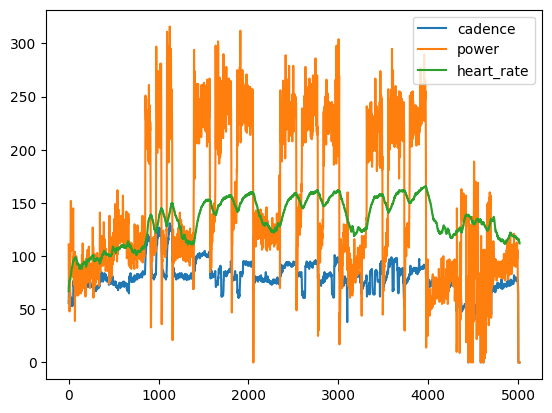

In [21]:
df[["cadence", "power", "heart_rate"]].plot()

In [22]:
df.timestamp.min(), df.timestamp.max(), df.timestamp.std()

(Timestamp('2024-02-20 23:51:53+0000', tz='UTC'),
 Timestamp('2024-02-21 01:15:29+0000', tz='UTC'),
 Timedelta('0 days 00:24:08.427480637'))

timestamp, position_lat, position_long, distance, heart_rate, altitude, speed, power, cadence, enhanced_speed, enhanced_altitude


<Axes: xlabel='timestamp'>

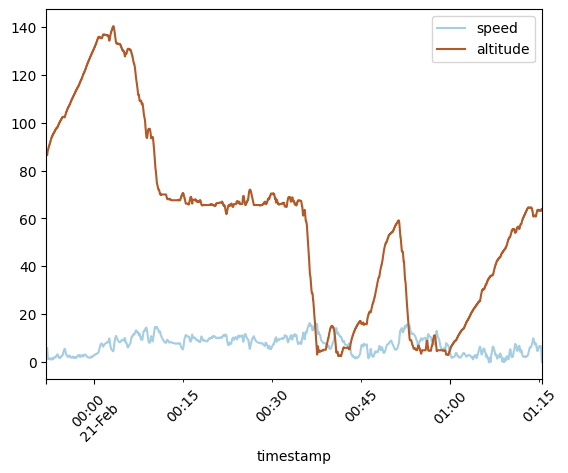

In [23]:
print(", ".join(df.columns))
df.set_index("timestamp")[["speed", "altitude"]].plot(rot=45, colormap="Paired")  # https://matplotlib.org/stable/gallery/color/colormap_reference.html
